---
title: "ColormaNN manuscript figures - PanUKB - Variance explained by factors"
author: "Saikat Banerjee"
format:
  html: default
date: "2025-07-24"
file-modified: "2025-07-24"
abstract: "High quality plots used for PanUKB results."

---

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import re

import matplotlib
import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils

mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)

In [2]:
# NYGC Color Palette
nygc_colors = {
    'brown': '#7F0814',
    'darkred': '#d42e12',
    'orange': '#F37239',
    'darkyellow': '#F79320',
    'yellow': '#FFE438',
    'darkblue': '#003059',
    'blue': '#266DB6',
    'lightblue': '#A3D5ED',
    'darkgreen': '#006838',
    'green': '#0A8A42',
    'lightgreen': '#74B74A',
    'yellowgreen': '#BAD75F',
    'darkgray': '#1A1A1A',
    'gray': '#666666',
    'lightgray': '#CCCCCC',
    'khaki': '#ADA194',
    'darkkhaki': '#5E514D',
}

# Style sheet for manuscript
mpl_stylesheet.banskt_presentation(dpi = 300, fontsize = 28, 
    splinecolor = nygc_colors['darkgray'], black = nygc_colors['darkgray'])

In [3]:
data_dir = "/gpfs/commons/home/sbanerjee/work/npd/PanUKB/data"
result_dir = "/gpfs/commons/home/sbanerjee/npddata/panukb/results/colormann-svd"

zscore_df = pd.read_pickle(os.path.join(data_dir, f"modselect/zscore_noRx.pkl"))
trait_df  = pd.read_pickle(os.path.join(data_dir, f"modselect/traits_all_with_desc.pkl"))
trait_df  = trait_df.query('trait_type != "prescriptions"')

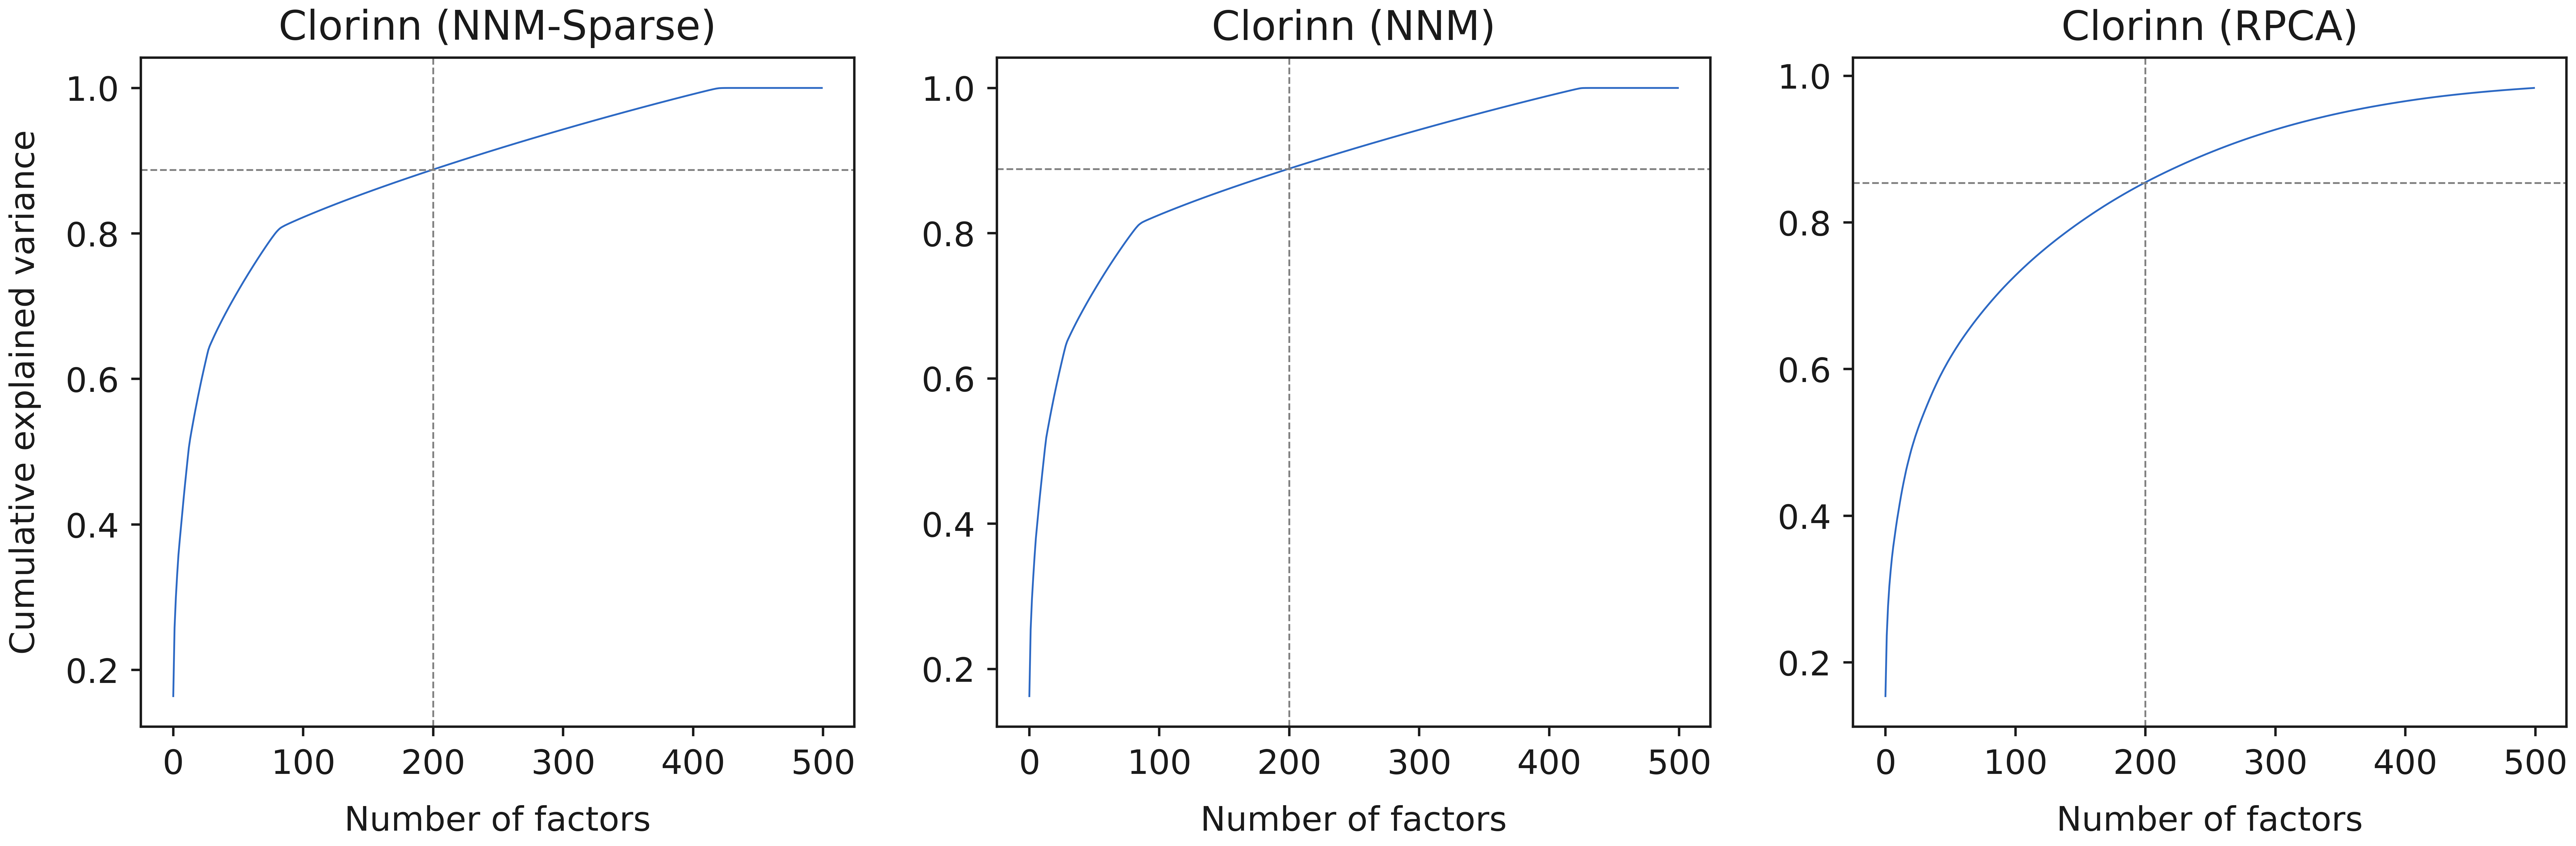

In [11]:
methods = ['nnm-sparse', 'nnm', 'rpca']
    
method_labels = {
    "rpca" : "Clorinn (RPCA)",
    "nnm" : "Clorinn (NNM)",
    "nnm-sparse" : "Clorinn (NNM-Sparse)",
    "truncated_svd": "DeGAs",
    "factorgo": "FactorGO",
}


fig = plt.figure(figsize = (36,10))
axs = [fig.add_subplot(131), fig.add_subplot(132), fig.add_subplot(133)]

for i, method in enumerate(methods):
    method_resdir = os.path.join(result_dir, method, "noRx")
    with (open(f"{method_resdir}/pca_comps.pkl", "rb")) as fh:
        U, S, V = pickle.load(fh)
    S_squared = np.square(S)
    explained_variance = np.cumsum(S_squared / np.sum(S_squared))
    axs[i].plot(np.arange(500), explained_variance[:500])
    axs[i].axvline(x = 200, linestyle='dashed', color = 'grey')
    axs[i].axhline(y = explained_variance[199], linestyle='dashed', color = 'grey')
    axs[i].set_xlabel("Number of factors")
    if i == 0:
        axs[i].set_ylabel("Cumulative explained variance")
    axs[i].set_title(method_labels[method], pad = 15)
    
plt.savefig('../plots/colormann-manuscript/panukb_explained_variance.pdf', bbox_inches='tight')
plt.show()